IMPORTS

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Imports OK")

Imports OK


Chargements des données 

In [4]:
from pathlib import Path


def find_data_raw_root():
    current = Path.cwd()
    for _ in range(4):
        candidate = current / "data" / "raw"
        if candidate.exists():
            return candidate
        current = current.parent
    raise FileNotFoundError("Impossible de trouver le dossier data/raw depuis le répertoire courant.")

DATA_DIR = find_data_raw_root()

train = pd.read_csv(DATA_DIR / "train(2).csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")
test = pd.read_csv(DATA_DIR / "test_public.csv")

print("DATA_DIR :", DATA_DIR)
print("Train :", train.shape)
print("Validation :", validation.shape)
print("Test :", test.shape)

DATA_DIR : c:\Users\delim\OneDrive\Bureau\ML CHALLENGE\data\raw
Train : (180371, 43)
Validation : (38651, 43)
Test : (38651, 43)


Identifier les variables numériques les plus prometteuses

In [5]:
train.describe().T.sort_values("std", ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
stcpb,180371.0,1.008685e+09,1.368207e+09,0.0,0.000000,0.000000,2.009900e+09,4.294959e+09
dtcpb,180371.0,1.005105e+09,1.364346e+09,0.0,0.000000,0.000000,1.998585e+09,4.294882e+09
sload,180371.0,7.053927e+07,1.851258e+08,0.0,12305.468260,739422.875000,8.000000e+07,5.600000e+09
dload,180371.0,6.581049e+05,2.412133e+06,0.0,0.000000,1777.832397,2.225204e+04,2.242273e+07
sbytes,180371.0,8.512775e+03,1.755446e+05,24.0,114.000000,528.000000,1.356000e+03,1.435577e+07
rate,180371.0,9.108393e+04,1.599175e+05,0.0,30.782919,2952.755752,1.250000e+05,1.000000e+06
dbytes,180371.0,1.463912e+04,1.537443e+05,0.0,0.000000,178.000000,1.070000e+03,1.465753e+07
response_body_len,180371.0,2.040782e+03,5.073798e+04,0.0,0.000000,0.000000,0.000000e+00,6.558056e+06
sjit,180371.0,5.417643e+03,4.862695e+04,0.0,0.000000,1.070089,2.807635e+03,1.483831e+06
sinpkt,180371.0,9.091395e+02,6.906143e+03,0.0,0.008000,0.385000,5.816499e+01,6.000999e+04


Corrélation entre variables

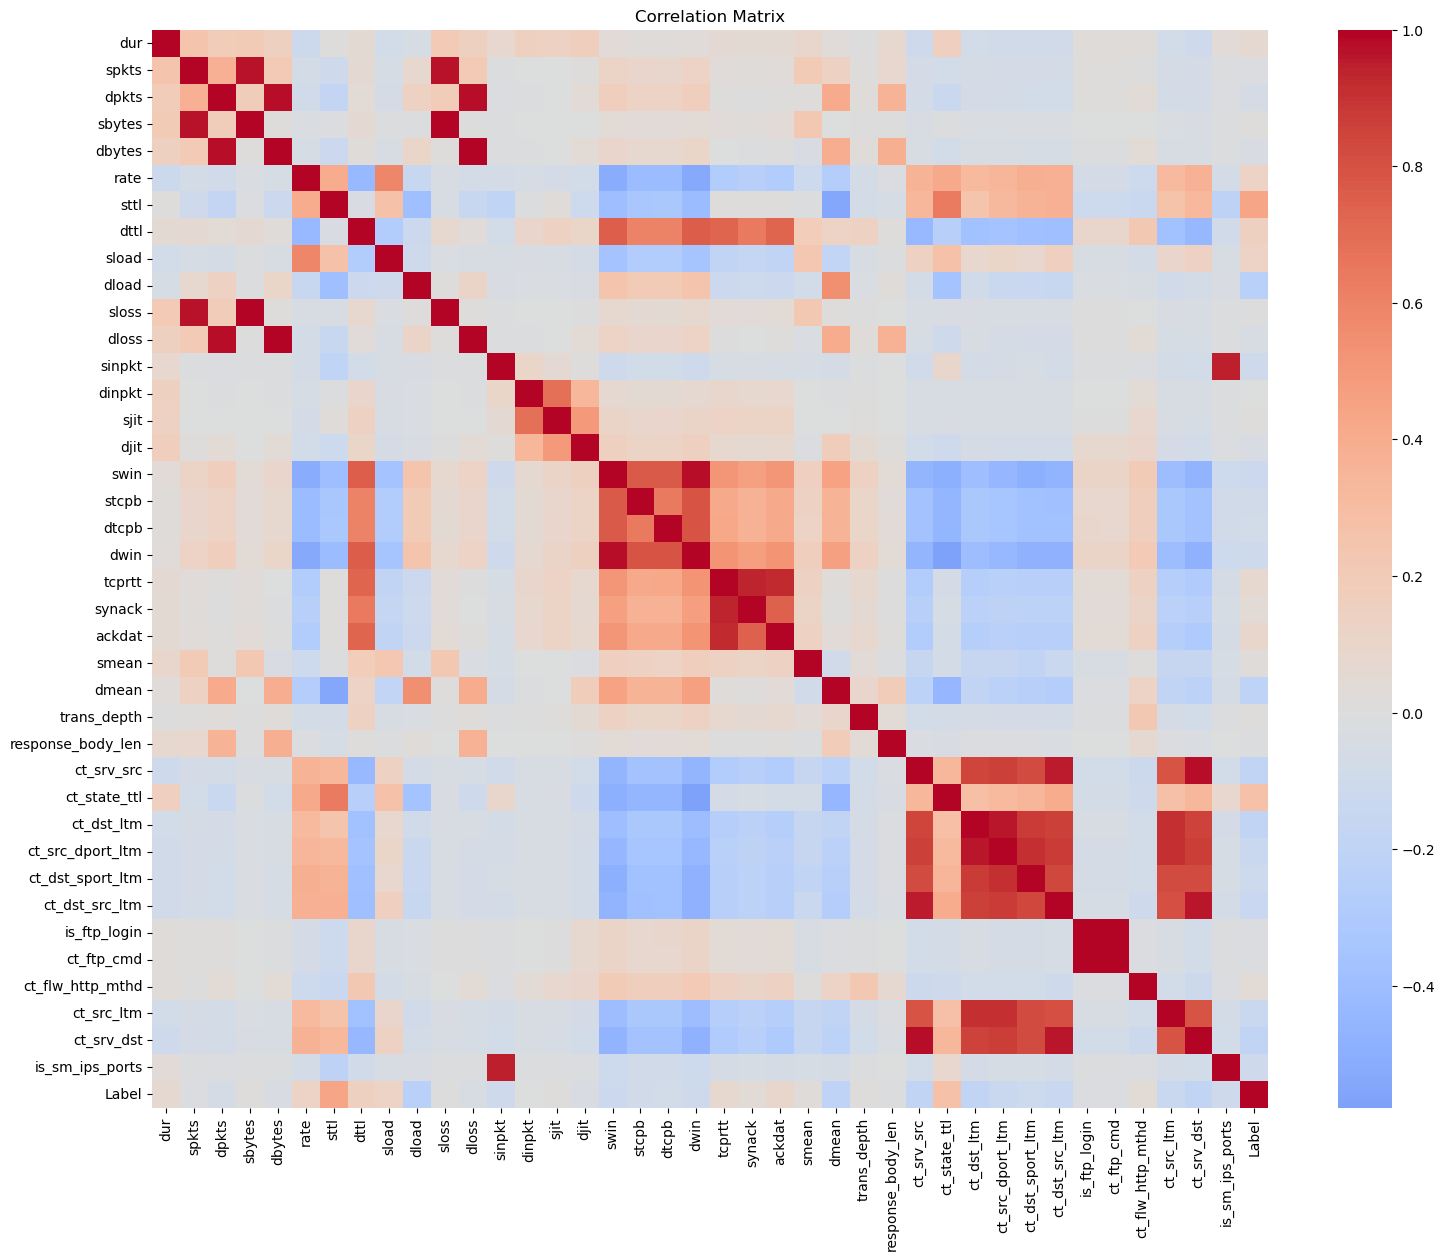

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = train.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(18,14))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

Comparaison des moyennes par classe

In [7]:
features_to_check = [
    "dur",
    "sbytes",
    "dbytes",
    "rate",
    "sttl",
    "dttl"
]

for col in features_to_check:
    print("\n" + "="*50)
    print(col)
    print(train.groupby("Label")[col].mean())


dur
Label
0    1.029010
1    0.060979
2    2.128957
3    2.734443
4    2.462004
5    1.035798
6    1.384237
7    2.102064
8    0.367004
9    1.272694
Name: dur, dtype: float64

sbytes
Label
0     4106.885407
1      437.196777
2    29320.791093
3     6567.316934
4    18578.238753
5      789.150342
6      817.905016
7     1234.739424
8      528.897921
9     2325.172131
Name: sbytes, dtype: float64

dbytes
Label
0    26370.677327
1     1461.225485
2    17528.534829
3      519.649423
4    23977.603826
5     2473.722807
6      297.303095
7      311.693440
8      147.655955
9    69516.286885
Name: dbytes, dtype: float64

rate
Label
0     19330.952445
1    209648.815786
2     68537.763974
3     66792.073847
4    145793.299275
5     99861.169821
6    145749.158214
7    146095.075608
8     94853.575868
9     23923.831802
Name: rate, dtype: float64

sttl
Label
0     94.988633
1    252.492368
2    171.865948
3    253.466297
4    230.604875
5    252.931468
6    209.501601
7    248.440221
8    254